# Notebook 08 - Cross-Dataset Validation

The external-validation payoff. The score regressor is trained on DS3, and here
I test whether that learned relationship transfers to two datasets it never saw:
DS4, the untouched holdout, and DS2, the negative control that has no usable
signal. If the pattern holds on an independent dataset and collapses on the
control, that is real evidence of generalisation rather than a quirk of one
source.

The datasets share only a subset of features (four
with DS4, three with DS2) and use different units, so transfer is measured on a
shared-feature model with features and target standardised per dataset. These
numbers therefore are not the 0.737 headline, which uses all features; they
answer a different question. And classification is not part of this: DS3 and DS4
have no risk label and almost no overlap with DS1's behavioural features, so
cross-dataset validation applies to the score model only.



Run both transfers. The validator trains a fresh XGBoost on DS3 restricted
to the shared features, then applies it to each target with per-dataset
standardisation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tabulate import tabulate

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml import config
from ml.cross_validator import CrossDatasetValidator

sns.set_theme(style="whitegrid")

validator = CrossDatasetValidator()
validator.evaluate(config.REGRESSION_HOLDOUT)   # DS4
validator.evaluate(config.REGRESSION_CONTROL)   # DS2

for key, result in validator.results_.items():
    print(f"{key}: shared features = {result['shared_features']}")
print()
print(tabulate(validator.summary(), headers="keys", tablefmt="github"))

ds4: shared features = ['study_hours', 'attendance', 'previous_score', 'sleep_hours']
ds2: shared features = ['study_hours', 'attendance', 'assignment_completion']

| target   | role    |   n_shared |   source_r2 |   source_r |   target_r2 |   target_r |   target_rmse_sd |
|----------|---------|------------|-------------|------------|-------------|------------|------------------|
| ds4      | holdout |          4 |       0.498 |      0.706 |       0.333 |      0.596 |            0.817 |
| ds2      | control |          3 |       0.549 |      0.742 |      -0.554 |      0.005 |            1.246 |


Reading the table:

- **DS4 (holdout).** On DS3's own test split the shared-feature model reaches
  R-squared 0.50 (correlation 0.71). Transferred to DS4, which the model has
  never touched, it still explains a third of the variance (R-squared 0.33,
  correlation 0.60). That drop is expected and healthy: performance degrades on
  an independent dataset but the relationship clearly survives.
- **DS2 (control).** The same procedure collapses to correlation 0.005 and
  negative R-squared. The DS3 relationship simply does not exist in DS2, which is
  the whole point of keeping it as a control. It also reassures me that the DS4
  result is a real signal and not something the pipeline manufactures for any
  dataset.

Source versus transfer, side by side.

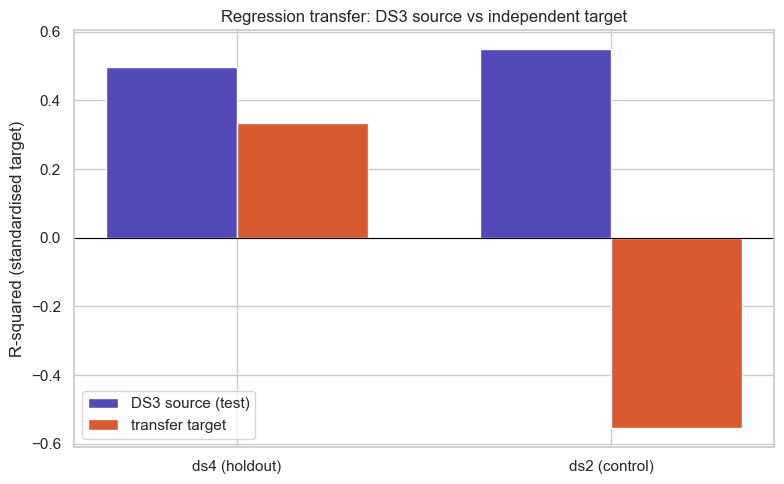

In [2]:
summary = validator.summary()
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(summary))
width = 0.35
ax.bar(x - width / 2, summary["source_r2"], width, label="DS3 source (test)", color=config.BRAND_PRIMARY)
ax.bar(x + width / 2, summary["target_r2"], width, label="transfer target", color=config.RISK_PALETTE["High Risk"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{i} ({summary.loc[i, 'role']})" for i in summary.index])
ax.set_ylabel("R-squared (standardised target)")
ax.set_title("Regression transfer: DS3 source vs independent target")
ax.legend()
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "cross_dataset_transfer_r2.png", dpi=120, bbox_inches="tight")
plt.show()

The scatter of predicted against actual (both standardised) makes the
contrast concrete: a clear diagonal trend for the DS4 holdout, essentially a
cloud for the DS2 control.

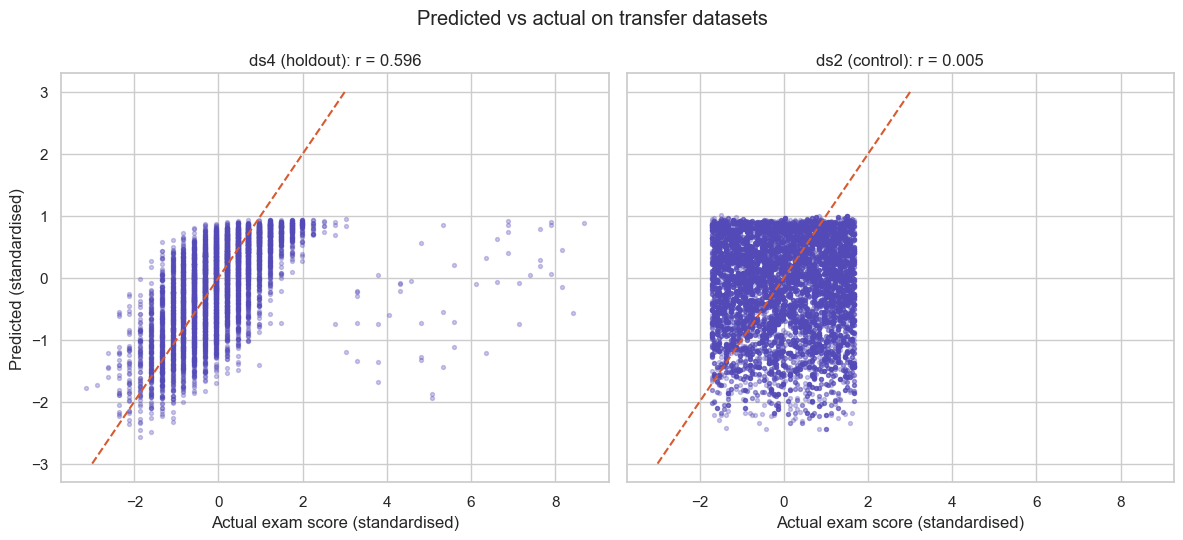

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, key in zip(axes, [config.REGRESSION_HOLDOUT, config.REGRESSION_CONTROL]):
    result = validator.results_[key]
    actual = result["target_actual_z"]
    predicted = result["target_predicted"]
    role = "holdout" if key == config.REGRESSION_HOLDOUT else "control"
    ax.scatter(actual, predicted, s=8, alpha=0.3, color=config.BRAND_PRIMARY)
    ax.plot([-3, 3], [-3, 3], color=config.RISK_PALETTE["High Risk"], linestyle="--")
    ax.set_title(f"{key} ({role}): r = {result['target']['pearson_r']}")
    ax.set_xlabel("Actual exam score (standardised)")
axes[0].set_ylabel("Predicted (standardised)")
fig.suptitle("Predicted vs actual on transfer datasets")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "cross_dataset_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## Key takeaways

- The DS3-trained relationship generalises to DS4, the untouched holdout:
  R-squared 0.50 on source falls to 0.33 on transfer, correlation 0.60. A model
  that works on a dataset it never saw is the definition of external validation.
- The same procedure fails on the DS2 control (correlation 0.005), which is the
  correct behaviour for a dataset with no feature signal and confirms the DS4
  result is not an artifact.
- Transfer is measured on shared features with per-dataset standardisation, so
  these figures are not the production 0.737 and are not meant to be. They are a
  generalisation test, and the generalisation holds where it should and fails
  where it should.
- Cross-dataset validation is a regression-track result. The behavioural
  clustering and risk classification are DS1-only, since no other dataset carries
  those features or the risk label.